In [2]:
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import numpy as np


def compute_distance(X, n_components=50):
    """
    Perform PCA to reduce the dimension, then compute the average pairwise Euclidean distance.
    
    Parameters:
        X (torch.Tensor): Data tensor of shape (N, C)
        n_components (int): Target dimension after PCA.
    
    Returns:
        float: The average pairwise Euclidean distance in the reduced space.
    """
    X_np = X.cpu().float().numpy()
    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X_np)
    pairwise_dists = pdist(X_reduced, metric='euclidean')
    return np.sum(pairwise_dists)


In [5]:
import torch
import torch.nn.functional as F
import math
import numpy as np
from scipy.spatial.distance import pdist

# Load data and apply L2 normalization for each sample (row)
x = torch.load("/home/sz3684/diffusion/flux_svd_iccv/tensors/x/x_2.pt")
x = x[0]
x = F.normalize(x, dim=1)
print('Distance for x:', compute_distance(x))

def custom_attention(x):
    """
    Compute standard attention where q, k, and v are normalized versions of x.
    
    Parameters:
        x (torch.Tensor): Input tensor
    
    Returns:
        torch.Tensor: The output after attention is applied
    """
    # Normalize x to compute queries, keys, and values
    q = F.normalize(x, dim=-1)
    k = F.normalize(x, dim=-1)
    v = F.normalize(x, dim=-1)
    
    d_k = q.size(-1)
    # Compute scaled dot-product attention scores
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    attn = F.softmax(scores, dim=-1)
    output = torch.matmul(attn, v)
    return output

# Compute custom_attention and get the final output distance
for _ in range(20):
    output_virgin = custom_attention(x)
distance_custom = compute_distance(output_virgin)
print("custom_attention distance:", distance_custom)

def get_gaussian_projection_matrix(x, out_dim):
    """
    Generate a Gaussian random projection matrix.
    
    Parameters:
        x (torch.Tensor): Input tensor, used to determine input dimension.
        out_dim (int): Output dimension for the projection.
    
    Returns:
        torch.Tensor: Gaussian projection matrix of shape (in_dim, out_dim)
    """
    in_dim = x.size(-1)
    proj_matrix = torch.randn(in_dim, out_dim, device=x.device, dtype=x.dtype)
    return proj_matrix

def gaussian_attention(x):
    """
    Compute attention using Gaussian random projection.
    Each call generates a new projection matrix.
    
    Parameters:
        x (torch.Tensor): Input tensor
    
    Returns:
        torch.Tensor: The output after Gaussian-based attention is applied
    """
    out_dim = x.shape[-1]
    # Generate a new Gaussian projection matrix
    proj_matrix = get_gaussian_projection_matrix(x, out_dim)
    # Project x using the Gaussian matrix
    x_proj = torch.matmul(x, proj_matrix)
    
    # Normalize projected x to compute queries, keys, and values
    q = F.normalize(x_proj, dim=-1)
    k = F.normalize(x_proj, dim=-1)
    v = F.normalize(x_proj, dim=-1)
    # v = F.normalize(x, dim=-1)
    
    d_k = q.size(-1)
    # Compute scaled dot-product attention scores
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    attn = F.softmax(scores, dim=-1)
    output = torch.matmul(attn, v)
    return output

# Compute gaussian_attention and get the final output distance
for _ in range(20):
    output_gaussian = gaussian_attention(x)
distance_gaussian = compute_distance(output_gaussian)
print("gaussian_attention distance:", distance_gaussian)


Distance for x: 7519291.995478215
custom_attention distance: 9644.852958909449
gaussian_attention distance: 10119.742308788374


In [6]:
import torch
import torch.nn.functional as F
import math
import numpy as np
from scipy.spatial.distance import pdist

# Load data and apply L2 normalization for each sample (row)
x = torch.load("/home/sz3684/diffusion/flux_svd_iccv/tensors/x/x_2.pt")
x = x[0]
x = F.normalize(x, dim=1)
print('Distance for x:', compute_distance(x))

def multihead_custom_attention(x, num_heads=8):
    """
    Compute standard multi-head attention where queries, keys, and values 
    are obtained by normalizing x and then splitting into multiple heads.
    
    Parameters:
        x (torch.Tensor): Input tensor of shape (N, d_model)
        num_heads (int): Number of attention heads
    
    Returns:
        torch.Tensor: Output tensor of shape (N, d_model) after attention is applied
    """
    d_model = x.size(-1)
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
    head_dim = d_model // num_heads

    # Normalize input for q, k, v
    q = F.normalize(x, dim=-1)
    k = F.normalize(x, dim=-1)
    v = F.normalize(x, dim=-1)
    
    # Reshape x for multi-head: (N, d_model) -> (N, num_heads, head_dim)
    q = q.view(-1, num_heads, head_dim)
    k = k.view(-1, num_heads, head_dim)
    v = v.view(-1, num_heads, head_dim)
    
    # Transpose to shape (num_heads, N, head_dim)
    q = q.transpose(0, 1)
    k = k.transpose(0, 1)
    v = v.transpose(0, 1)
    
    # Compute scaled dot-product attention for each head
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)  # (num_heads, N, N)
    attn = F.softmax(scores, dim=-1)
    output = torch.matmul(attn, v)  # (num_heads, N, head_dim)
    
    # Concatenate heads and reshape back to (N, d_model)
    output = output.transpose(0, 1).contiguous().view(-1, d_model)
    return output

# Compute multi-head custom attention and its average distance
for _ in range(20):
    output_multi_custom = multihead_custom_attention(x, num_heads=8)
distance_multi_custom = compute_distance(output_multi_custom)
print("multihead_custom_attention distance:", distance_multi_custom)

def get_gaussian_projection_matrix(x, out_dim):
    """
    Generate a Gaussian random projection matrix.
    
    Parameters:
        x (torch.Tensor): Input tensor, used to determine input dimension.
        out_dim (int): Output dimension for the projection.
    
    Returns:
        torch.Tensor: Gaussian projection matrix of shape (in_dim, out_dim)
    """
    in_dim = x.size(-1)
    proj_matrix = torch.randn(in_dim, out_dim, device=x.device, dtype=x.dtype)
    return proj_matrix

def multihead_gaussian_attention(x, num_heads=8):
    """
    Compute multi-head attention using Gaussian random projection.
    Each call generates a new projection matrix, and the queries, keys,
    and values are computed from the projected x.
    
    Parameters:
        x (torch.Tensor): Input tensor of shape (N, d_model)
        num_heads (int): Number of attention heads
    
    Returns:
        torch.Tensor: Output tensor of shape (N, d_model) after attention is applied
    """
    d_model = x.size(-1)
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
    head_dim = d_model // num_heads

    # Generate a new Gaussian projection matrix and project x
    proj_matrix = get_gaussian_projection_matrix(x, d_model)
    x_proj = torch.matmul(x, proj_matrix)
    
    # Normalize projected x to compute q, k, and v
    q = F.normalize(x_proj, dim=-1)
    k = F.normalize(x_proj, dim=-1)
    v = F.normalize(x_proj, dim=-1)
    
    # Reshape for multi-head attention: (N, d_model) -> (N, num_heads, head_dim)
    q = q.view(-1, num_heads, head_dim)
    k = k.view(-1, num_heads, head_dim)
    v = v.view(-1, num_heads, head_dim)
    
    # Transpose to shape (num_heads, N, head_dim)
    q = q.transpose(0, 1)
    k = k.transpose(0, 1)
    v = v.transpose(0, 1)
    
    # Compute scaled dot-product attention for each head
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)  # (num_heads, N, N)
    attn = F.softmax(scores, dim=-1)
    output = torch.matmul(attn, v)  # (num_heads, N, head_dim)
    
    # Concatenate heads and reshape back to (N, d_model)
    output = output.transpose(0, 1).contiguous().view(-1, d_model)
    return output

# Compute multi-head Gaussian attention and its average distance
for _ in range(20):
    output_multi_gaussian = multihead_gaussian_attention(x, num_heads=8)
distance_multi_gaussian = compute_distance(output_multi_gaussian)
print("multihead_gaussian_attention distance:", distance_multi_gaussian)

Distance for x: 7519272.553886283
multihead_custom_attention distance: 2602.394872890044
multihead_gaussian_attention distance: 3248.663425875351


100%|██████████| 104/104 [02:57<00:00,  1.71s/it]


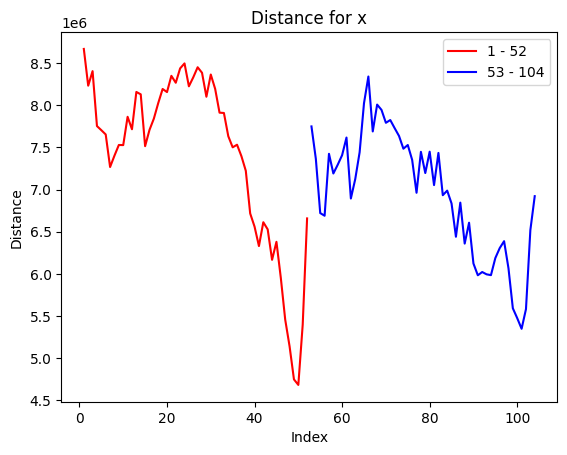

In [16]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

interval = 52 
start_idx = 1
end_idx = 104  

distances = []
for i in tqdm(range(start_idx, end_idx + 1)):
    x = torch.load(f"/home/sz3684/diffusion/flux_svd_iccv/tensors/x/x_{i}.pt")
    distances.append(compute_distance(x[0]))

x_values = list(range(start_idx, start_idx + len(distances)))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta']

for idx in range(0, len(distances), interval):
    xs = x_values[idx: idx + interval]
    ys = distances[idx: idx + interval]
    color = colors[(idx // interval) % len(colors)]
    label = f"{xs[0]} - {xs[-1]}"
    plt.plot(xs, ys, color=color, label=label)

plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('Distance for x')
plt.legend()
plt.show()
